In [1]:
# -------------------------
# Standard Library Imports
# -------------------------
import copy, gc, glob, json, multiprocessing, os, random, re, shutil, sys, time, warnings, logging, numbers, tqdm
from importlib import reload
from pprint import pprint

os.environ['GRISM_CAL_DIR'] = '/data/grism_cal'

# -------------------------
# Scientific Libraries
# -------------------------
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
from PIL import Image
from scipy import interpolate
from scipy.optimize import minimize
import matplotlib.patches as patches


# -------------------------
# Astropy
# -------------------------
import astropy.constants as ac
import astropy.units as u
from astropy import table
from astropy.convolution import Box1DKernel, convolve
from astropy.coordinates import SkyCoord, concatenate
from astropy.io import fits, ascii
from astropy.modeling import functional_models, models
from astropy.modeling.models import Gaussian2D
from astropy.nddata import Cutout2D, NDData
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.table import Table
from astropy.visualization.wcsaxes import WCSAxes
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.visualization import astropy_mpl_style, AsinhStretch

# -------------------------
# Other Astronomy packages
# -------------------------
from photutils.detection import DAOStarFinder
from photutils.psf import EPSFBuilder, extract_stars
from astroquery.sdss import SDSS
from stpsf import NIRCam
os.environ['STPSF_PATH'] = '/home/yichenliu/stpsf-data'


# -------------------------
# Plotting and Pringting Style
# -------------------------
import scienceplots
plt.style.use(astropy_mpl_style)
plt.style.use(['bright', 'science', 'no-latex', 'notebook'])
plt.rcParams['image.origin'] = 'lower'
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams['image.interpolation'] = 'none'
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

# -------------------------
# Suppress Astropy Warnings
# -------------------------
warnings.simplefilter('ignore', FITSFixedWarning)

# -------------------------
# Jupyter Display Settings
# -------------------------
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


# -------------------------
# GPU/ML related
# -------------------------
import torch
from torch.autograd import grad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [2]:
from dingo import grism, utils, galaxy, kinematics, fitting, plot

In [3]:
LOG = logging.getLogger(__name__)
LOG.setLevel(logging.INFO)

# Only add handler once 
if not LOG.handlers:
    console_handler = logging.StreamHandler()
    formatter = logging.Formatter(
        '%(asctime)s - %(levelname)s - %(name)s - %(message)s',
        datefmt='%H:%M:%S'  # Or '%Y-%m-%d %H:%M:%S' for full timestamp
    )
    console_handler.setFormatter(formatter)
    LOG.addHandler(console_handler)


In [4]:
def recursive_reload(module, visited=None):
    import importlib, types
    if visited is None:
        visited = set()
    if module in visited:
        return
    visited.add(module)
    for attr in dir(module):
        sub = getattr(module, attr)
        if isinstance(sub, types.ModuleType) and sub.__name__.startswith(module.__name__):
            recursive_reload(sub, visited)
    importlib.reload(module)


In [5]:
def asinhstretch(im): return np.arcsinh(im/sigma_clipped_stats(im)[2])

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Get the data

In [7]:
IMAGE_DIR = '/data/sapphires/all_mosaics/YF_working/direct_imaging' # XXX: Using Yoshi's stage 2 result
GRISM_DIR = '/data/sapphires/grism/'

# coord_gal = SkyCoord('04h15m46.987s-24d10m50.0s') # ID3700
# z = 1.123 # ID3700
# ID15665
coord_gal = SkyCoord(64.007840*u.deg, -24.148910*u.deg)
z = 1.161

line_wavelengths = 1.875*(1 + z) # nm, Pa alpha
r_fit = 40

imaging data

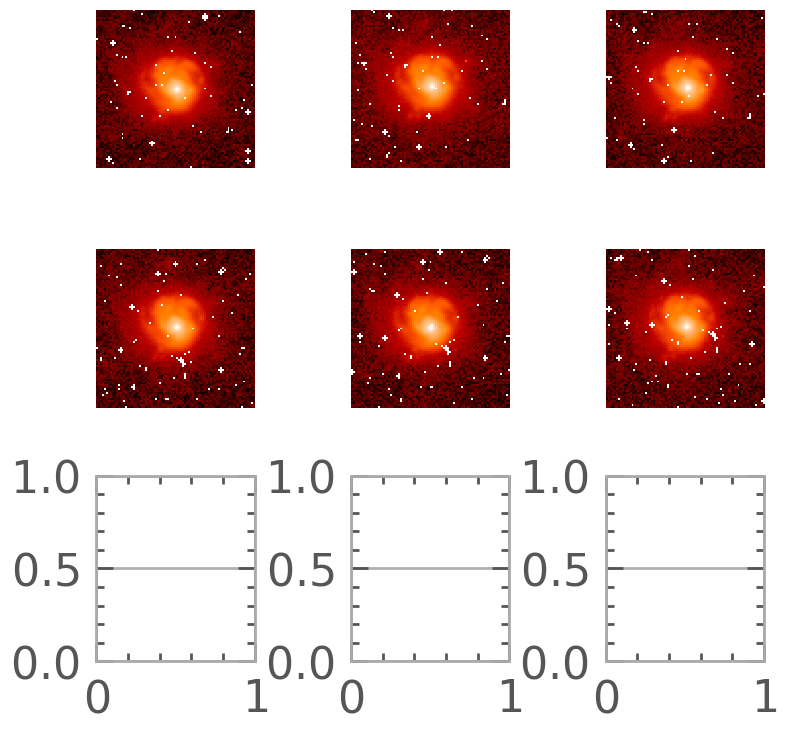

In [8]:
image_paths_temp = glob.glob(os.path.join(IMAGE_DIR, 'obsnum1[1-3]*', 'F444W_imaging', '*_crf.fits')) #'jw064341[1-3]*nrc[a-b]long_rate_lv1.5.fits'))

image_paths = []
for image_path in image_paths_temp: 
    with fits.open(image_path) as hdu:
        wcs = WCS(hdu['SCI'].header)
    if wcs.footprint_contains(coord_gal): 
        image_paths.append(image_path)

# plot

fig, axs = plt.subplots(3, 3, figsize=[4, 4])
axs = axs.flatten()

cutouts = []
for i in range(len(image_paths)):
    with fits.open(image_paths[i]) as hdu: 
        image_data = hdu['SCI'].data
        image_wcs = WCS(hdu['SCI'].header)

    cutout = Cutout2D(asinhstretch(image_data), coord_gal, r_fit*2+1, image_wcs, mode='partial', fill_value=np.nan)
    cutout_data = np.array(cutout.data, dtype=np.float32)
    cutout_wcs = cutout.wcs
    cx, cy = cutout.center_cutout
    cutouts.append(cutout_data)

    axs[i].imshow(cutout_data)
    axs[i].grid(None)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

(81, 81)


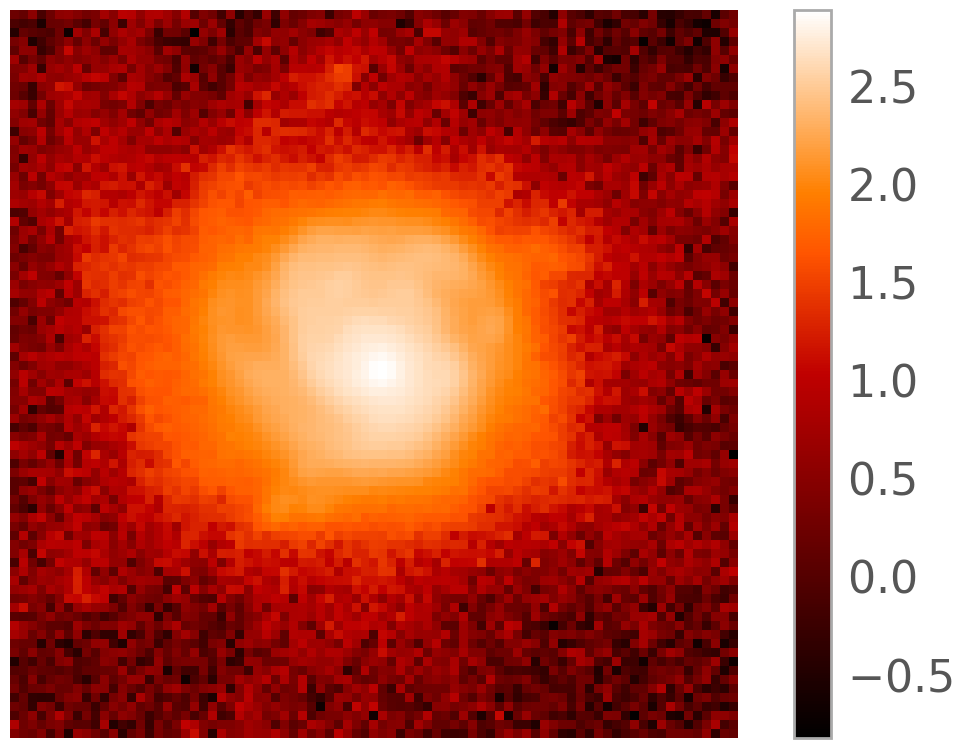

In [9]:
coadd_image = utils.coadd_images(cutouts)
print(coadd_image.shape)

plt.imshow(asinhstretch(coadd_image))
plt.grid(None)
plt.axis('off')

plt.tight_layout()
plt.colorbar()
plt.show()

grism data

302.6861336535055 328.88792118033973 A C
510.8563201200737 825.2038309918221 A R
516.3921402285457 831.5273678464704 A R
516.3860664270142 831.5352662962588 A R
510.8631919026932 825.2061241098938 A R
1084.1116957098948 24.27597604336767 A C
456.4798383452123 220.654495883102 A R
461.95196932263843 226.92082055739164 A R
297.2496277674684 322.5749559420911 A C
1073.1664329724235 11.844041337245542 A C
521.9001337126466 837.8663169654227 A R
521.9051253054884 837.8692831412923 A R
1078.6393095058913 18.057853343460167 A C
1078.640966455774 18.057986907046327 A C
1084.1123480998326 24.27780946655369 A C
467.42512981423545 233.19249944285826 A R
1073.1637646896795 11.841717047608967 A C
291.8100223306871 316.26702199321824 A C
18


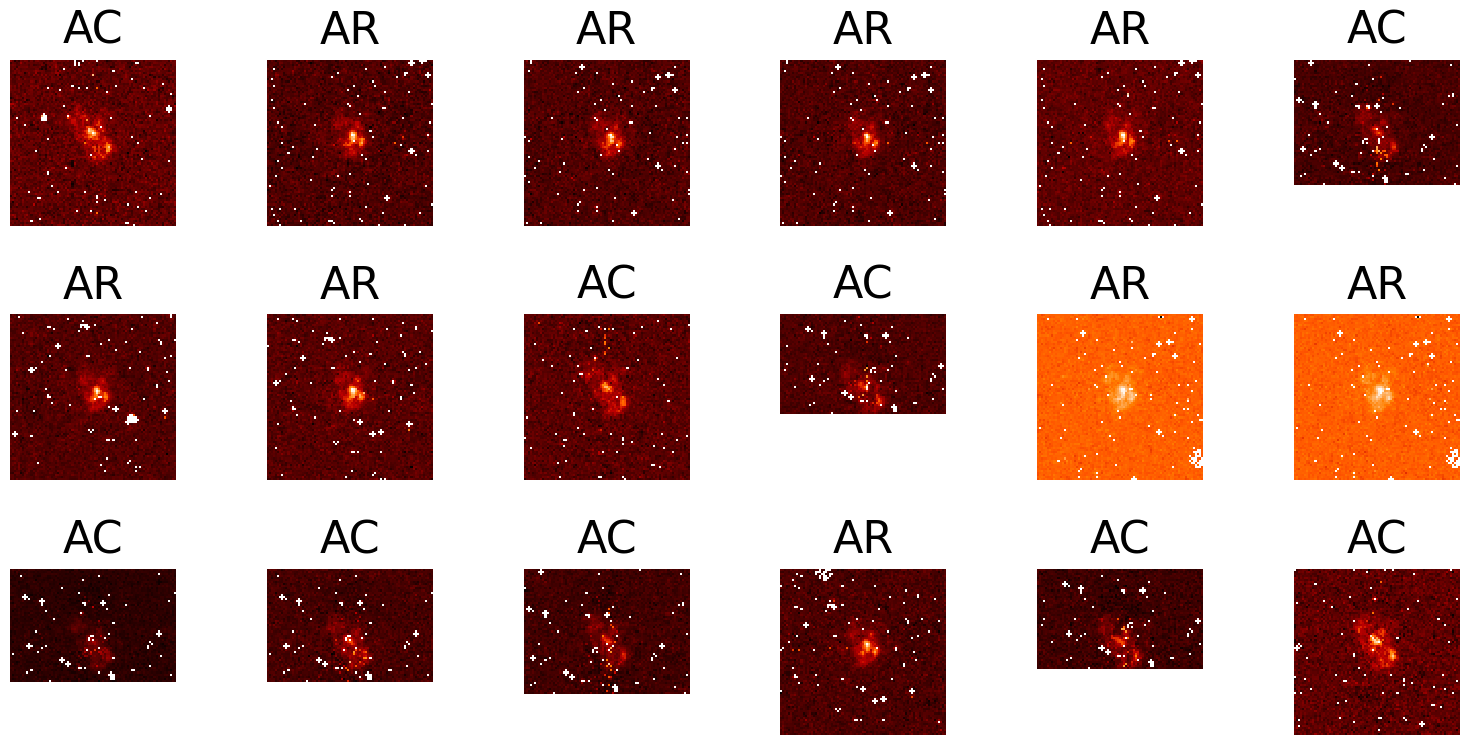

In [10]:
grism_paths_temp = glob.glob(os.path.join(GRISM_DIR, 'jw064341[1-3]*nrc[a-b]long_rate_lv1.5.fits'))

grism_paths = []
xlines_G = []
ylines_G = []
pupils = []
for grism_path in grism_paths_temp: 
    this_primary_head = fits.getheader(grism_path, 0)
    this_filter = this_primary_head['FILTER']
    this_module = this_primary_head['MODULE']
    this_pupil = this_primary_head['PUPIL'][-1]
    if this_filter.upper()=='F444W':
        WRANGE, this_spatial_model, this_disp_model = grism.load_nircam_wfss_model(pupil=this_pupil, module=this_module, filter=this_filter)

        with fits.open(grism_path) as hdu: 
            grism_wcs = WCS(hdu['SCI'].header)
            pixelx, pixely = grism_wcs.world_to_pixel(coord_gal)

        xline_on_G_img, yline_on_G_img = grism.find_pixel_location(
            WRANGE, this_spatial_model, this_disp_model, this_pupil,
            pixelx, pixely, line_wavelengths
        )
        if 0<xline_on_G_img<2048 and 0<yline_on_G_img<2048:
            print(xline_on_G_img, yline_on_G_img, this_module, this_pupil)
            grism_paths.append(grism_path)
            xlines_G.append(xline_on_G_img)
            ylines_G.append(yline_on_G_img)
            pupils.append(this_pupil)

print(len(grism_paths))

# plot

fig, axs = plt.subplots(3, 6, figsize=[8, 4])
axs = axs.flatten()

for i in range(len(grism_paths)):
    with fits.open(grism_paths[i]) as hdu: 
        grism_data = hdu['EMLINE'].data
        pupil = hdu[0].header['PUPIL']
        module = hdu[0].header['MODULE']

    gcutout = Cutout2D(grism_data, (xlines_G[i], ylines_G[i]), 2*r_fit+1, mode='partial', fill_value=np.nan)
    gcutout_data = np.array(gcutout.data, dtype=np.float32)
    axs[i].imshow(gcutout_data)
    axs[i].grid(None)
    axs[i].axis('off')
    axs[i].set_title(module+pupil[-1])

plt.tight_layout()
plt.show()

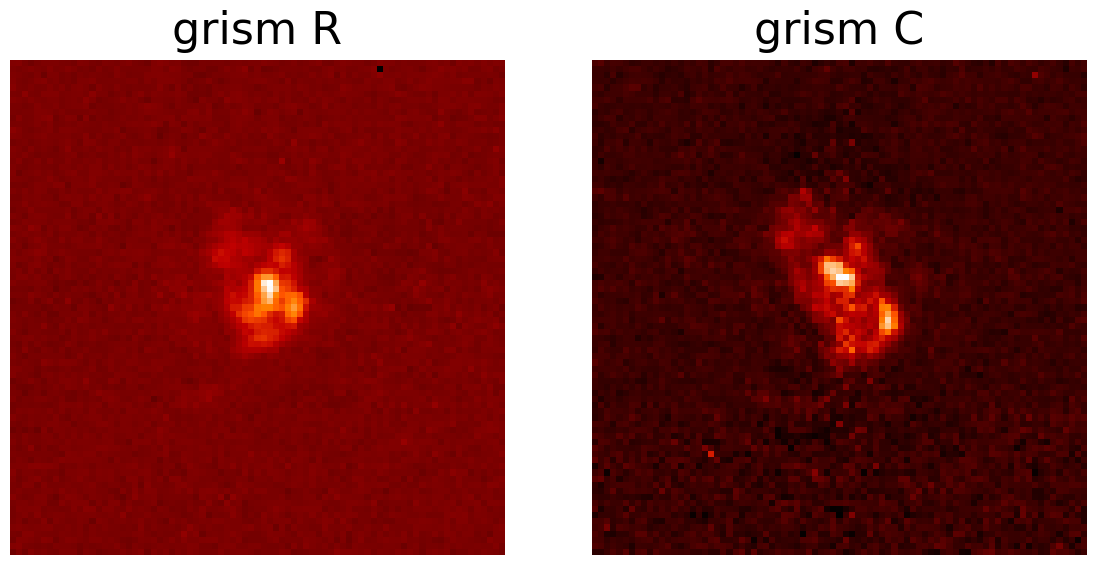

In [11]:
gcutouts = []
for i in range(len(grism_paths)):
    with fits.open(grism_paths[i]) as hdu: 
        grism_data = hdu['EMLINE'].data

    gcutout = Cutout2D(grism_data, (xlines_G[i], ylines_G[i]), r_fit*2+1, mode='partial', fill_value=np.nan)
    gcutout_data = np.array(gcutout.data, dtype=np.float32)
    gcutouts.append(gcutout_data)

gcutout_R = [g for g, p in zip(gcutouts, pupils) if p == 'R']
gcutout_C = [g for g, p in zip(gcutouts, pupils) if p == 'C']

coadd_R = utils.coadd_images(gcutout_R)
coadd_C = utils.coadd_images(gcutout_C)

coadd_R[np.isnan(coadd_R)] = 0
coadd_C[np.isnan(coadd_R)] = 0

# plot

fig, axs = plt.subplots(1, 2, figsize=[6, 3])
axs = axs.flatten()

axs[0].imshow(coadd_R)
axs[0].grid(None)
axs[0].axis('off')
axs[0].set_title('grism R')

axs[1].imshow(coadd_C)
axs[1].grid(None)
axs[1].axis('off')
axs[1].set_title('grism C')

plt.tight_layout()
plt.show()

save files

In [12]:
hdu = fits.PrimaryHDU(coadd_image)
hdu.writeto('ID15665/image.fits', overwrite=True)

hdu = fits.PrimaryHDU(coadd_R)
hdu.writeto('ID15665/R.fits', overwrite=True)

hdu = fits.PrimaryHDU(coadd_C)
hdu.writeto('ID15665/C.fits', overwrite=True)

## Fit Roataion Curve

22:12:35 - INFO - dingo.fitting - Starting fitting stage 1/2: method=Adam
22:12:36 - INFO - dingo.fitting - Stage 1, Step 1, loss=0.870, lr=0.05000, xy_iters=(17, 28)
22:12:44 - INFO - dingo.fitting - Stage 1, Step 500, loss=0.098, lr=0.05000, xy_iters=(10, 5)
22:12:52 - INFO - dingo.fitting - Stage 1, Step 1000, loss=0.099, lr=0.05000, xy_iters=(13, 5)
22:13:02 - INFO - dingo.fitting - Stage 1, Step 1500, loss=0.099, lr=0.05000, xy_iters=(16, 8)
22:13:12 - INFO - dingo.fitting - Stage 1, Step 2000, loss=0.100, lr=0.05000, xy_iters=(15, 8)
22:13:16 - INFO - dingo.fitting - Stage 1, Step 2500, loss=0.098, lr=0.00500, xy_iters=(1, 2)
22:13:16 - INFO - dingo.fitting - Starting fitting stage 2/2: method=Adam
22:13:16 - INFO - dingo.fitting - Stage 2, Step 1, loss=0.098, lr=0.00300, xy_iters=(29, 18)
22:13:20 - INFO - dingo.fitting - Stage 2, Step 500, loss=0.098, lr=0.00300, xy_iters=(3, 1)
22:13:24 - INFO - dingo.fitting - Stage 2, Step 1000, loss=0.098, lr=0.00212, xy_iters=(1, 1)
22:13:


[Velocity]
V_rot      = 506.8591
R_v        = 3.3512
x0_v       = 42.5087
y0_v       = 41.5563
theta_v    = 2.3243
inc_v      = 0.5040

[Dispersion R]
dx         = 0.6289
dy         = 0.4064
forward_model = None

[Dispersion C]
dx         = -0.2692
dy         = -0.3980
forward_model = None


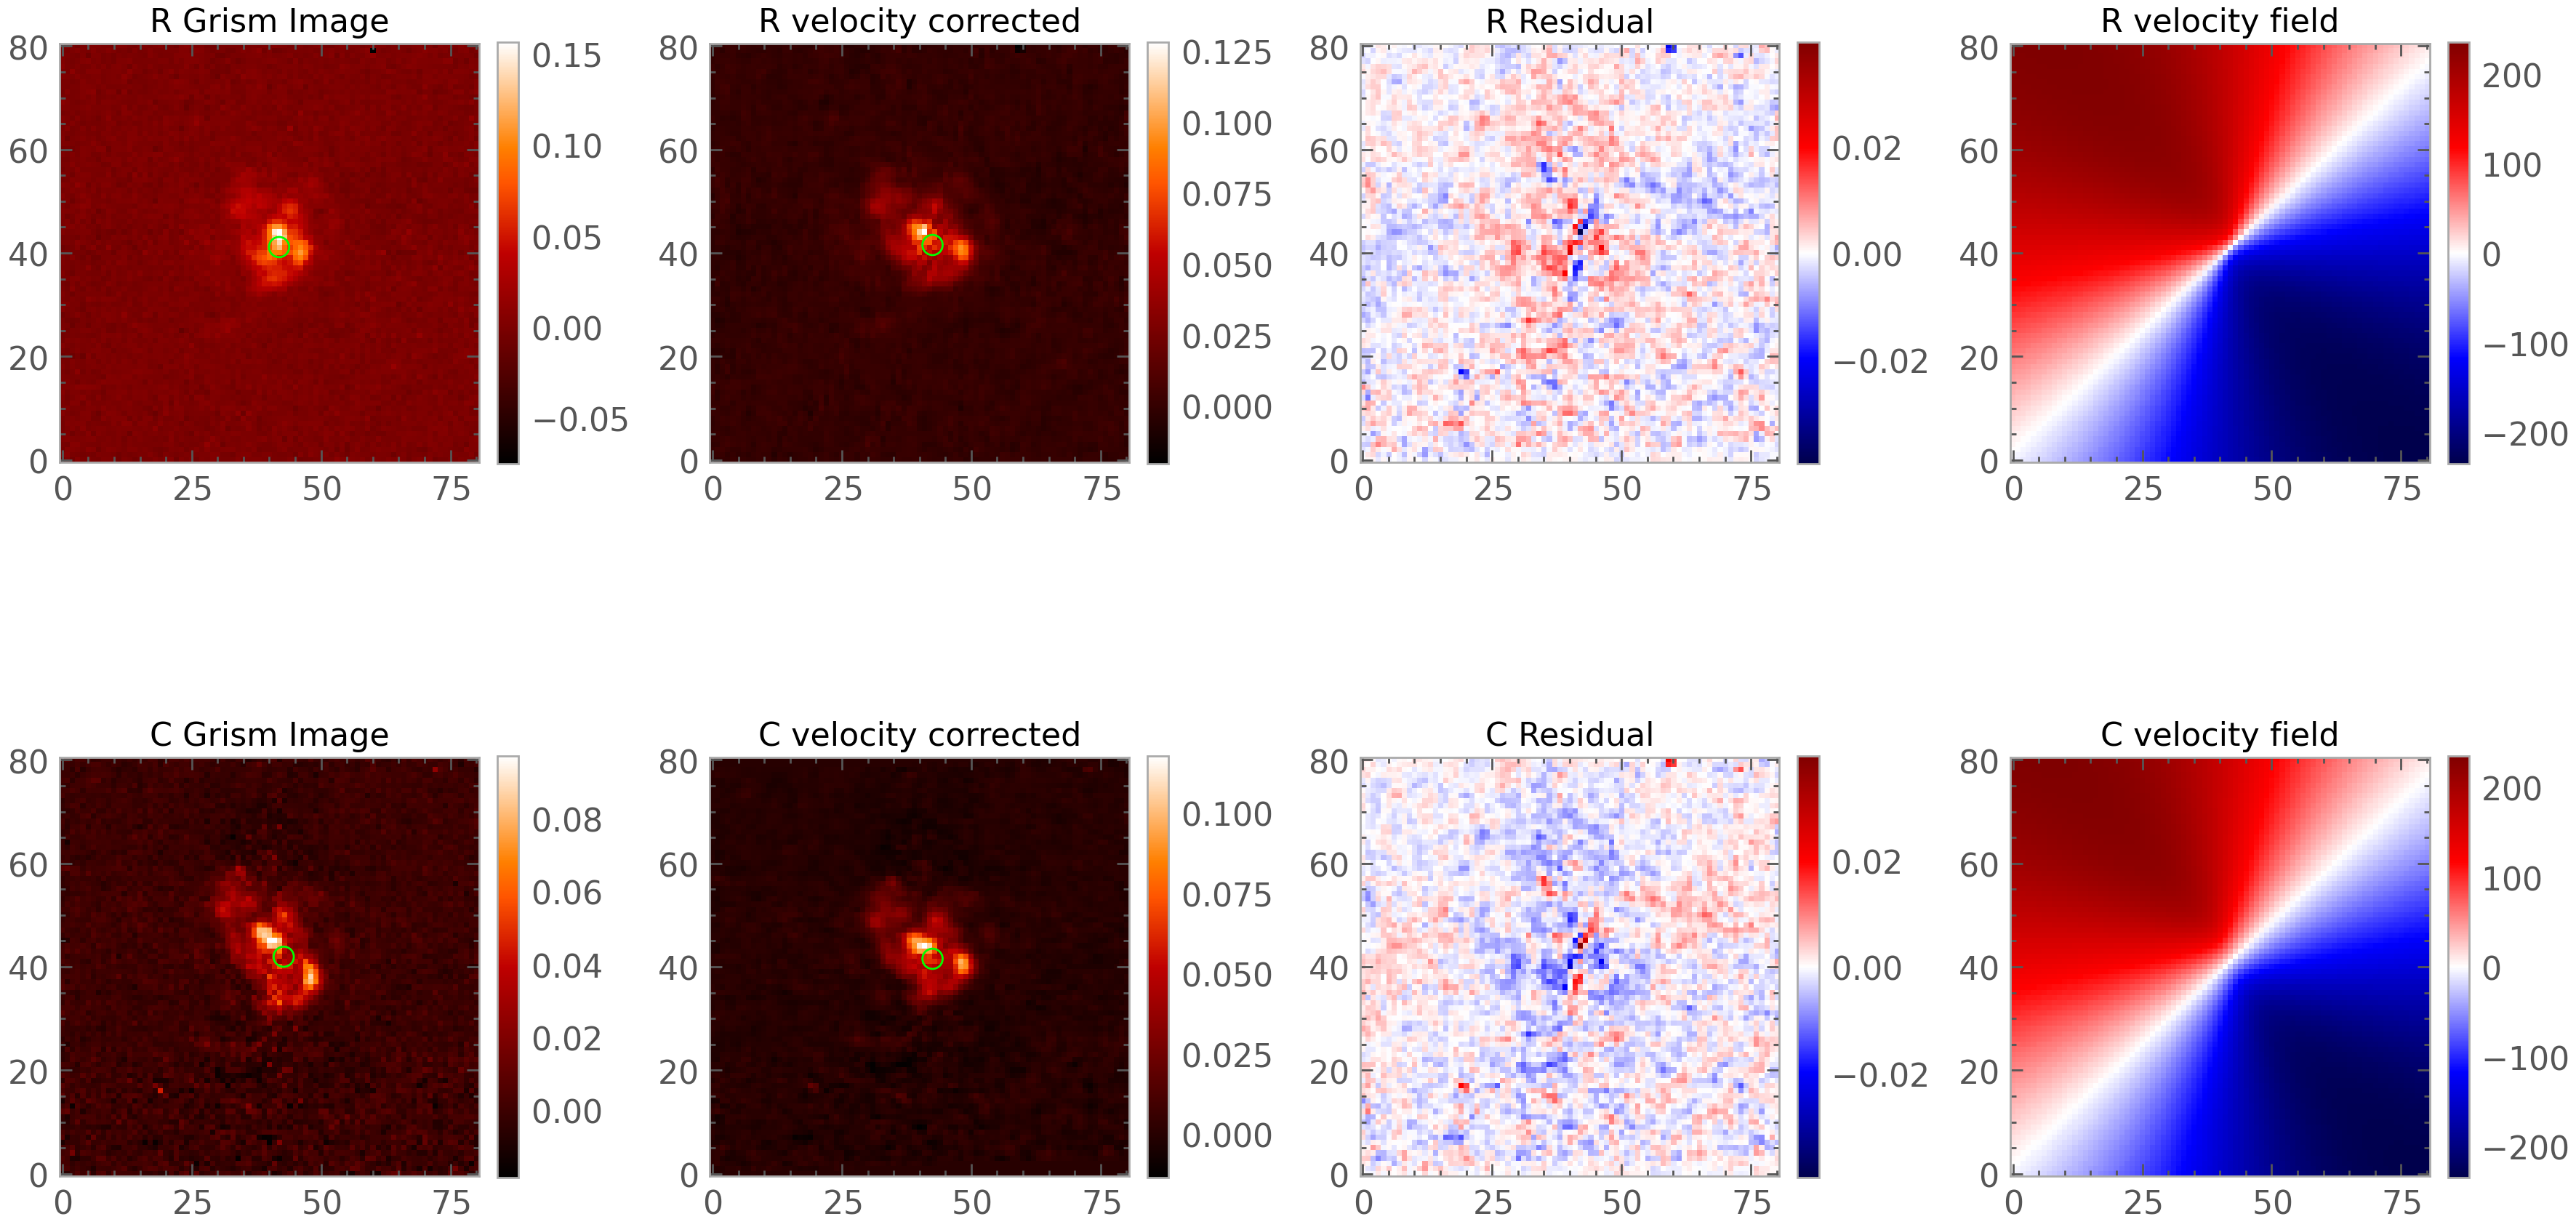

In [14]:
# ----------------------------------------------------------------------------
# Fit
# ----------------------------------------------------------------------------

kinematics_fitter = fitting.KinematicsFitter(config_path='ID15665/config_kinematics.yaml')
all_losses, all_lrs = kinematics_fitter.fit_all()

# ----------------------------------------------------------------------------
# Evaluate fitted model
# ----------------------------------------------------------------------------

image_R, image_C, vz_R, vz_C = kinematics_fitter.get_fitting_results()
velocity_params, dispersion_params_R, dispersion_params_C = kinematics_fitter.get_params()
true_grism_R, true_grism_C = kinematics_fitter.get_true_images()

# Velocity model parameters
def print_params(title, params):
    print(f'\n[{title}]')
    for name, param in params.items():
        if isinstance(param, (numbers.Number, np.number)):
            print(f'{name:10s} = {param:.4f}')
        else:
            print(f'{name:10s} = {param}')

print_params('Velocity', velocity_params)
print_params('Dispersion R', dispersion_params_R)
print_params('Dispersion C', dispersion_params_C)

# visualization
fig, axs = plt.subplots(2, 4, figsize=(18, 10))

plot.plot_kinematics_fitting_result(true_grism_R, image_R, vz_R, image_C, 'R', axs[0], velocity_params, dispersion_params_R)
plot.plot_kinematics_fitting_result(true_grism_C, image_C, vz_C, image_R, 'C', axs[1], velocity_params, dispersion_params_C)

plt.tight_layout()
plt.show()

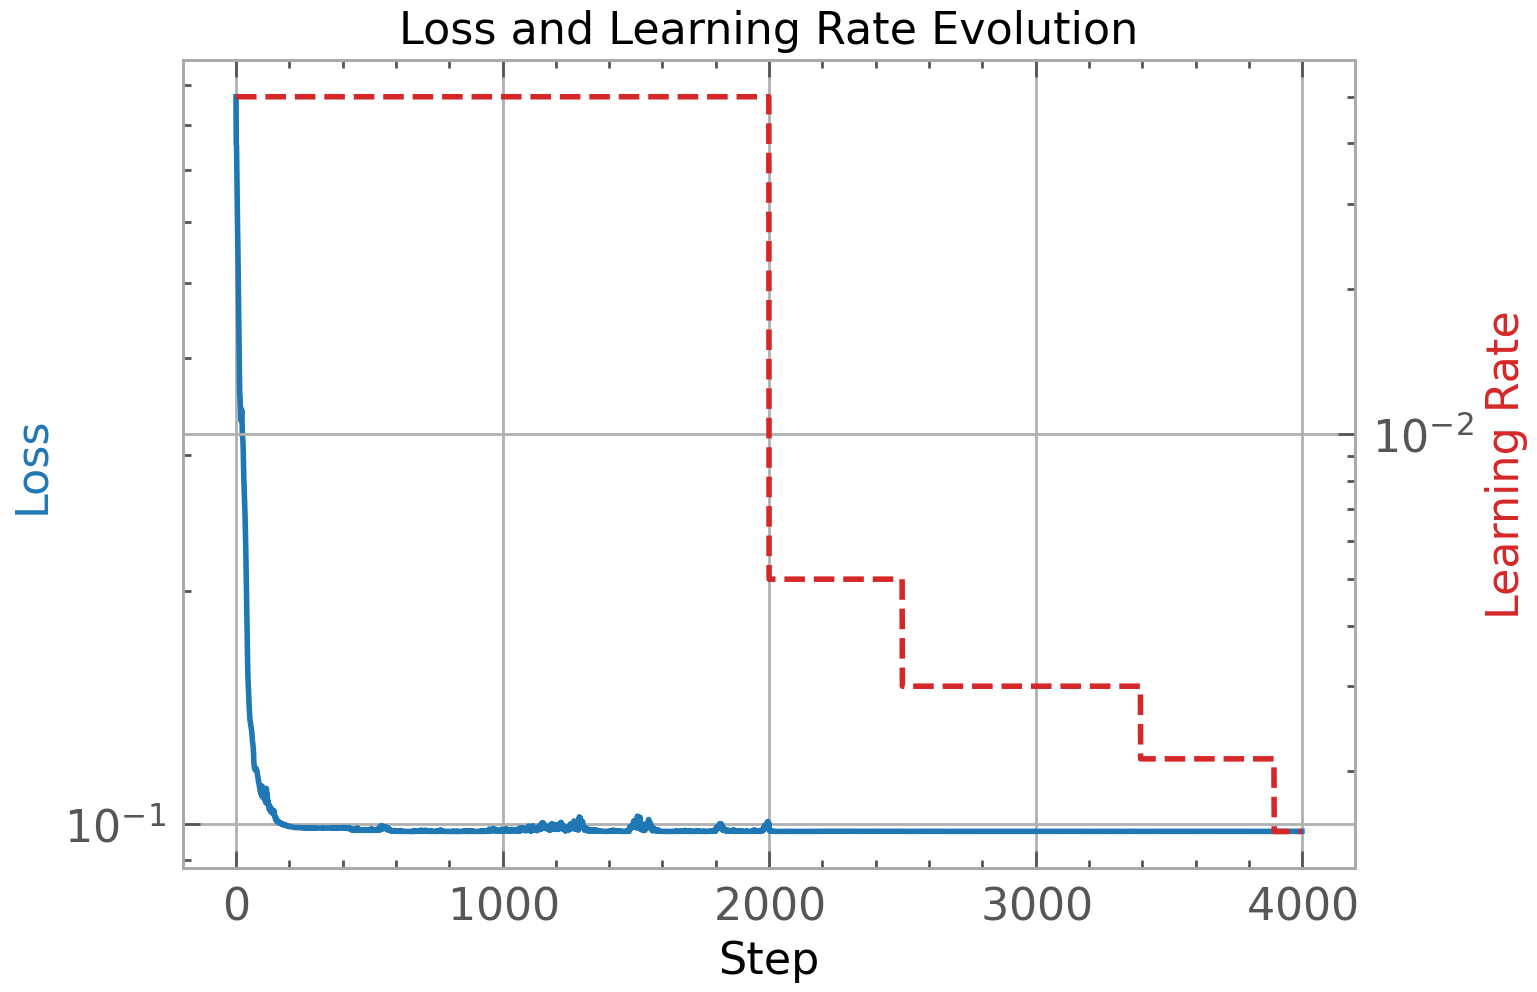

In [15]:
plot.plot_loss_and_lr(all_losses[0]+all_losses[1], all_lrs[0]+all_lrs[1])

In [16]:
# TODO: velocity dispersion
# TODO: update interpolation method (jacobian? not point-wise stretch?)

# TODO: select arctangent model
# TODO: select fitter mode 

plot rotation curve

/home/yichenliu/anaconda3/envs/py312/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


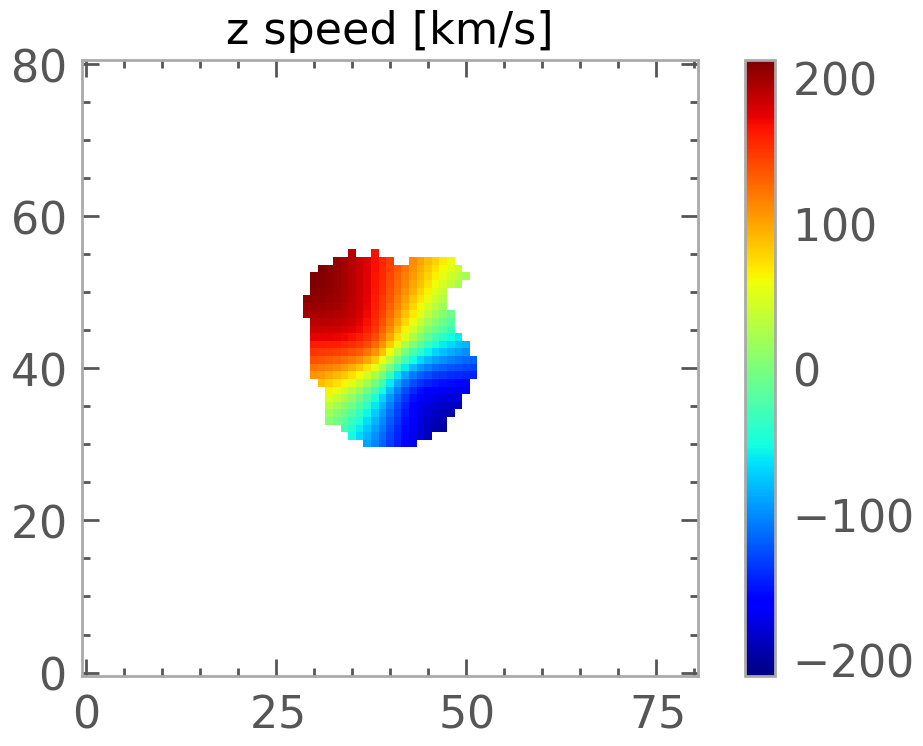

In [17]:
_, _, std = sigma_clipped_stats(coadd_image)
mask = coadd_image>std*5
nx, ny = coadd_image.shape

oversample = 1
y, x = torch.meshgrid(torch.arange(nx), torch.arange(ny))
V_rot = velocity_params['V_rot']
R_v = velocity_params['R_v']
# x0_v = velocity_params['x0_v']*oversample
# y0_v = velocity_params['y0_v']*oversample
x_pix, y_pix = cutout_wcs.world_to_pixel(coord_gal)
x0_v = torch.tensor(x_pix, device=device)
y0_v = torch.tensor(y_pix, device=device)
theta_v = torch.tensor(velocity_params['theta_v'], device=device)
inc_v = torch.tensor(velocity_params['inc_v'], device=device)

vz = kinematics.arctangent_disk_velocity_model(x, y, V_rot, R_v, x0_v, y0_v, theta_v, inc_v)
vz_np = vz.detach().cpu().numpy()
vz_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vz_np))

plt.imshow(vz_np, cmap='jet', vmin=-vmax, vmax=vmax)
plt.grid(None)
plt.colorbar()
plt.title('z speed [km/s]')
plt.show()

plot enclosed mass

In [18]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 1.123

# Angular diameter distance in Mpc
DA = cosmo.angular_diameter_distance(z)  # returns Quantity in Mpc

# Convert arcsec/pixel to kpc/pixel
arcsec_per_pixel = 0.063
kpc_per_arcsec = (DA.to(u.kpc) / u.rad).value * (1 / 206265)  # arcsec to rad
kpc_per_pixel = arcsec_per_pixel * kpc_per_arcsec

print(f'{kpc_per_pixel:.3f} kpc/pixel')


0.517 kpc/pixel


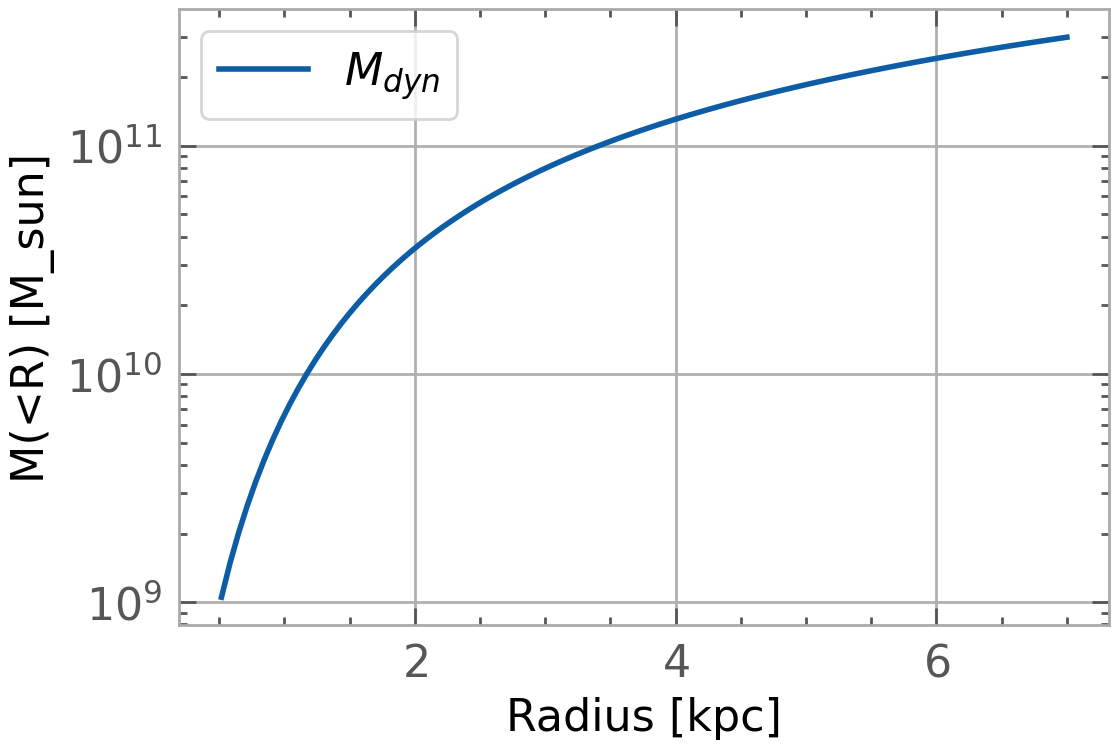

V_rot: 506.859100km/s
R_v: 1.732153kpc


In [19]:
def arctangent_dynamical_mass(r_kpc, V_rot=200., R_v=2., **kwargs):
    """
    Compute the dynamical mass M(<R) at radius R using the arctangent rotation curve.
    
    Parameters
    ----------
    r_kpc : torch.Tensor
        1D tensor of radius values in kpc.
    V_rot : float or torch.Tensor
        Maximum rotational velocity (km/s).
    R_v : float or torch.Tensor
        Turnover radius (kpc).
    
    Returns
    -------
    M_dyn : torch.Tensor
        Dynamical mass within radius R in units of solar masses (M_sun).
    """
    # Physical constant: G in units of d[kpc * (km/s)^2 / M_sun]
    G = 4.302e-6  # kpc * (km/s)^2 / M_sun

    # Arctangent rotation curve
    V = (2 / torch.pi) * V_rot * torch.atan(r_kpc / R_v)

    # M_dyn = V^2 * R / G
    M_dyn = (V**2 * r_kpc) / G

    return M_dyn

r_array = torch.linspace(kpc_per_pixel, 7, 100)  # 100 radii from 0.1 to 20 kpc
mass_profile = arctangent_dynamical_mass(
    r_array,
    V_rot=V_rot,
    R_v=R_v*kpc_per_pixel
)

# Plotting (optional)
plt.plot(r_array.detach().cpu().numpy(), mass_profile.detach().cpu().numpy(), label=r'$M_{dyn}$')
plt.xlabel('Radius [kpc]')
plt.ylabel('M(<R) [M_sun]')
plt.yscale('log')
plt.legend(frameon=True)
plt.grid(True)
plt.show()

print(f'V_rot: {V_rot:5f}km/s')
print(f'R_v: {R_v*kpc_per_pixel:5f}kpc')


overplot emission line map and velocity field

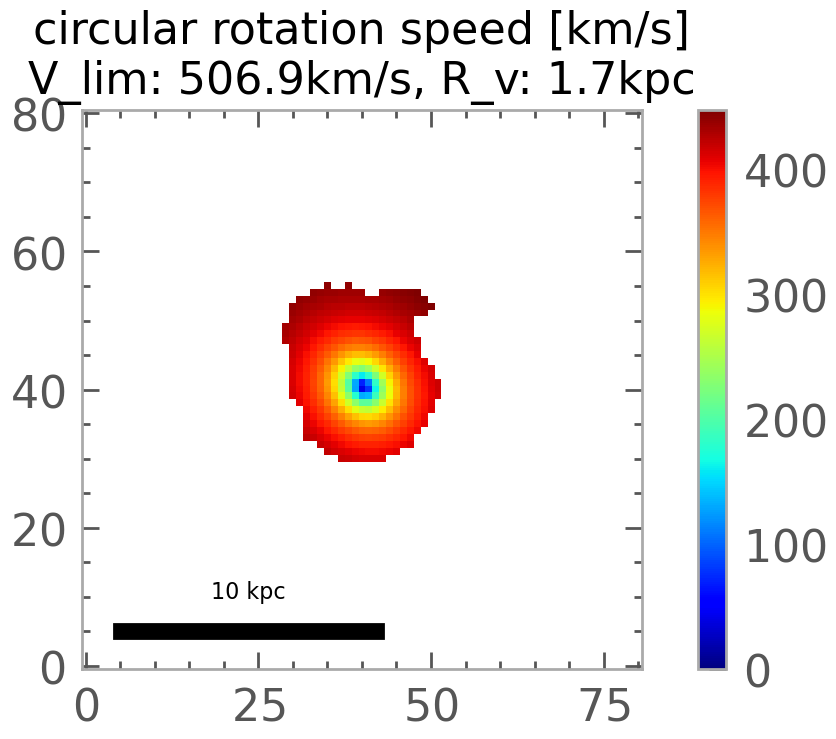

In [20]:
import numpy as np

def arctangent_disk_rotation_speed(x, y, V_rot=200., R_v=2., x0_v=0., y0_v=0., theta_v=0., inc_v=0., **kwargs):
    """
    Return the intrinsic circular velocity field (not LOS-projected).
    """
    # Shift to center
    dx = x - x0_v
    dy = y - y0_v

    # Rotate coordinates
    cos_t, sin_t = torch.cos(theta_v), torch.sin(theta_v)
    x_p = cos_t * dx + sin_t * dy
    y_p = -sin_t * dx + cos_t * dy

    # Deproject radius
    r = torch.sqrt(x_p**2 + (y_p / torch.cos(inc_v))**2 + 1e-8)

    # Arctangent rotation curve
    V_circ = (2 / torch.pi) * V_rot * torch.atan(r / R_v)

    return V_circ

_, _, std = sigma_clipped_stats(coadd_image)
mask = coadd_image>std*5
nx, ny = coadd_image.shape

oversample = 1
y, x = torch.meshgrid(torch.arange(nx), torch.arange(ny))
V_rot = velocity_params['V_rot']
R_v = velocity_params['R_v']
# x0_v = velocity_params['x0_v']*oversample
# y0_v = velocity_params['y0_v']*oversample
x_pix, y_pix = cutout_wcs.world_to_pixel(coord_gal)
x0_v = torch.tensor(x_pix, device=device)
y0_v = torch.tensor(y_pix, device=device)
theta_v = torch.tensor(velocity_params['theta_v'], device=device)
inc_v = torch.tensor(velocity_params['inc_v'], device=device)

vcirc = arctangent_disk_rotation_speed(x, y, V_rot, R_v, x0_v, y0_v, theta_v, inc_v)
vcirc_np = vcirc
vcirc_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vcirc_np))

# annotate

ang_diam_dist = cosmo.angular_diameter_distance(z).to('kpc')
kpc_per_arcsec = ang_diam_dist.value / 206265
pixel_scale = 0.031  # arcsec/pixel
pixels_per_kpc = 1 / (kpc_per_arcsec * pixel_scale)
bar_length_pix = int(10 * pixels_per_kpc)

y_bar = coadd_image.shape[0] * 0.05
x_bar_start = coadd_image.shape[1] * 0.05
rect = patches.Rectangle((x_bar_start, y_bar), bar_length_pix, 2, color='black')
plt.gca().add_patch(rect)
plt.text(x_bar_start + bar_length_pix / 2, y_bar + 5, '10 kpc',
		color='black', ha='center', va='bottom', fontsize=8)

plt.imshow(vcirc_np, cmap='jet', vmin=0, vmax=vmax)
plt.grid(None)
plt.colorbar()
plt.title(f'circular rotation speed [km/s]\nV_lim: {V_rot:.1f}km/s, R_v: {R_v*kpc_per_pixel:.1f}kpc')
plt.tight_layout()
plt.show()



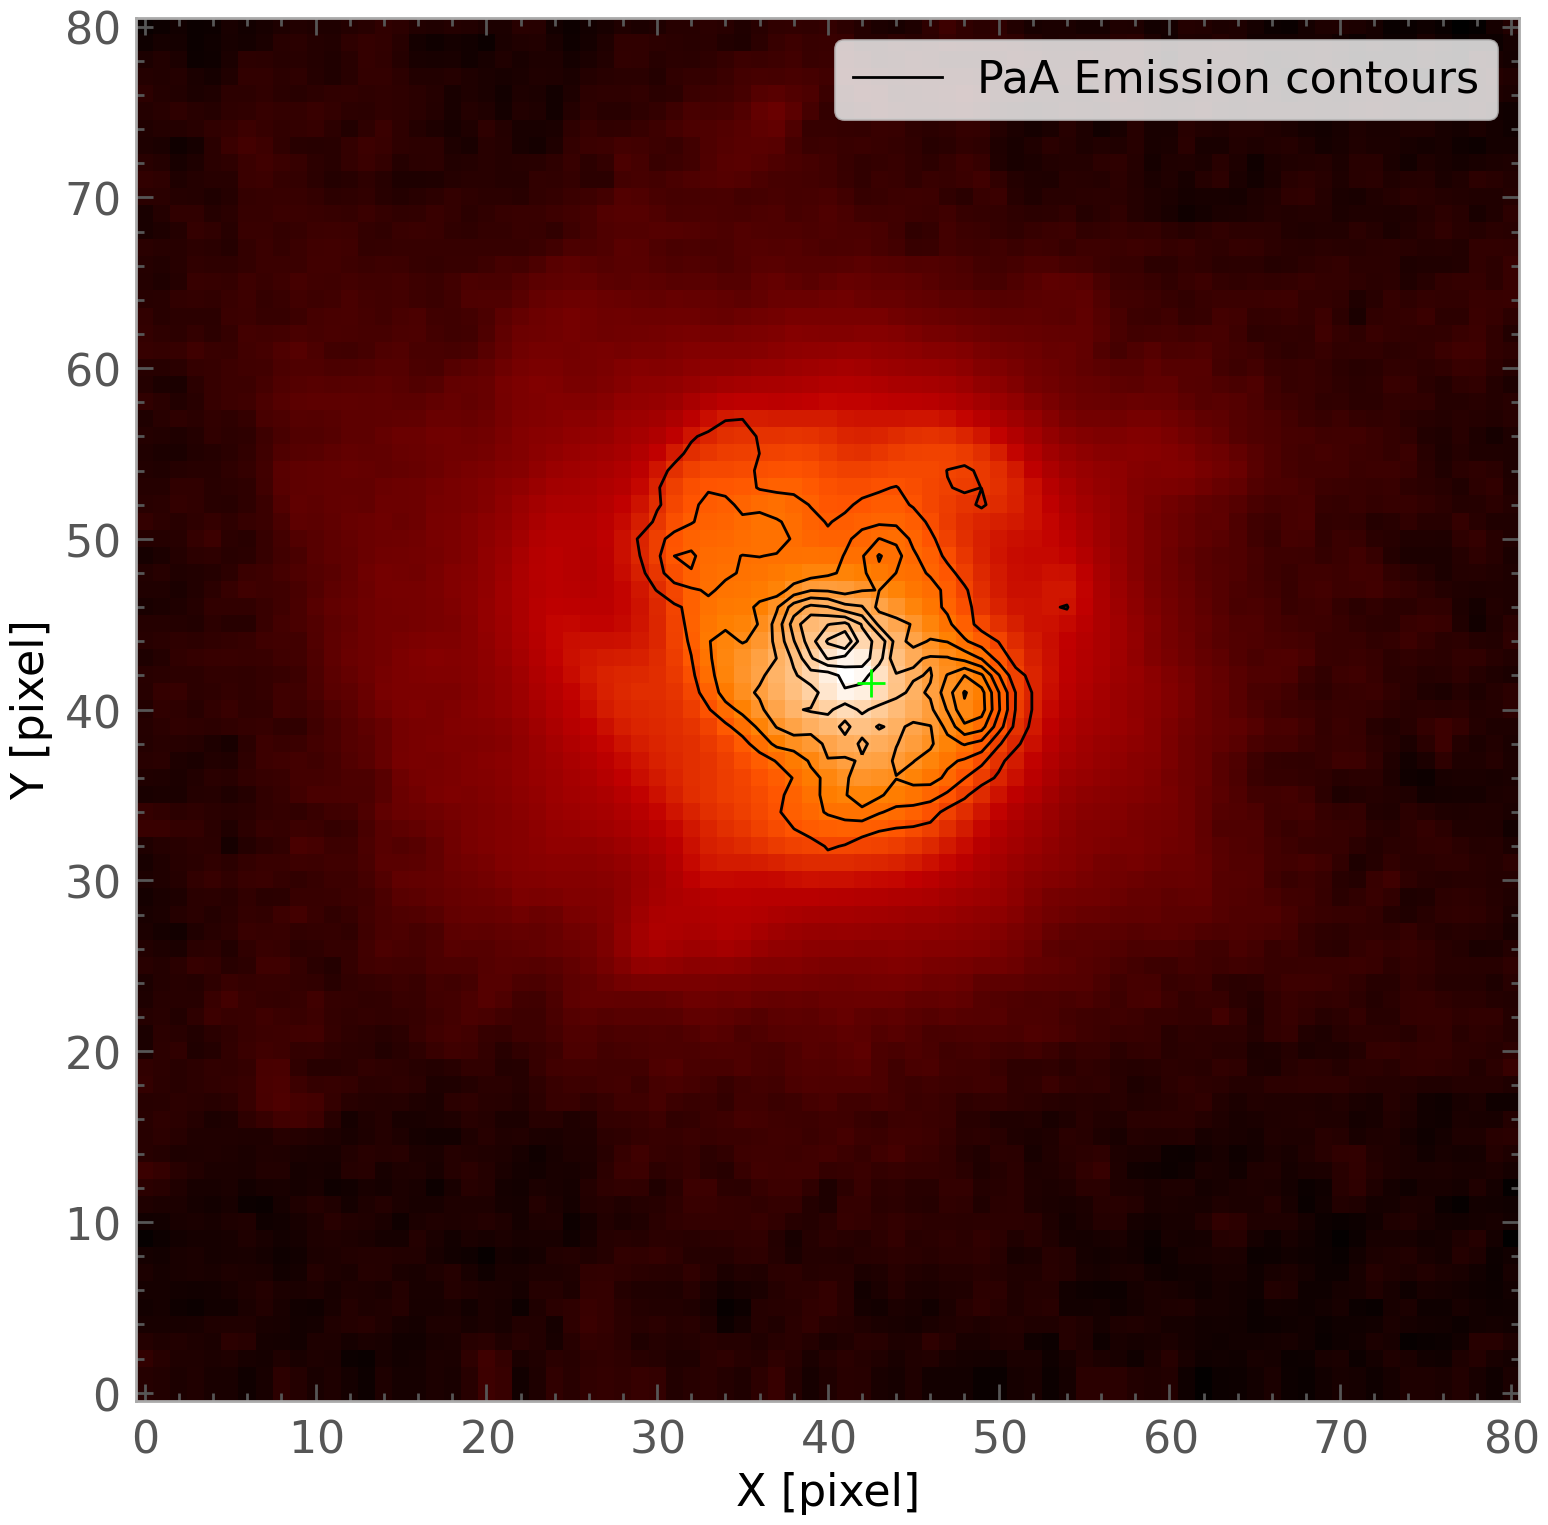

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from matplotlib.lines import Line2D
from astropy.stats import sigma_clipped_stats

# --- inputs (replace these with your actual arrays/values) ---
emission_image    = np.average([image_R, image_C], axis=0)
direct_image      = coadd_image
center_emission   = (velocity_params['x0_v'], velocity_params['y0_v'])
center_direct     = (43, 43)
contour_color     = 'black'
emline_boost      = 1.0
mask              = None
smoothing_sigma   = 0.0
ncontour          = 9
figsize           = (8, 8)

# --- shape and shift calculation ---
nx, ny = emission_image.shape
shift_y = center_emission[1] - center_direct[1]
shift_x = center_emission[0] - center_direct[0]

# shift direct image so its center matches the emission center
direct_image_shifted = scipy.ndimage.shift(
    direct_image,
    shift = (-shift_y, -shift_x),
    order = 1,
    mode  = 'nearest'
)

# --- prepare emission image for contours ---
# apply mask if provided
if mask is not None:
    emission_image_masked = np.where(mask, emission_image, np.nan)
else:
    emission_image_masked = emission_image

# boost and smooth
emission_image_boosted = emission_image_masked * emline_boost
emission_image_smooth  = scipy.ndimage.gaussian_filter(
    emission_image_boosted,
    sigma = smoothing_sigma
)

# --- set up contour levels ---
em_max = np.nanmax(emission_image_smooth)
em_levels = np.linspace(0.1 * em_max, em_max, ncontour)

# --- compute residual for later (optional) ---
# If you need the residual between two models:
# residual = model_image - diff_image
# resid_max = np.max(np.abs(residual))

# --- plotting ---
fig, ax = plt.subplots(figsize=figsize)

# show the shifted direct image
ax.imshow(direct_image_shifted, cmap='gist_heat', origin='lower')

# overlay emission-line contours
ax.contour(
    emission_image_smooth,
    levels = em_levels,
    colors = contour_color,
    linewidths = 1
)

# mark the emission center
ax.plot(
    center_emission[0],
    center_emission[1],
    marker='+' ,
    color='lime',
    markersize=10,
    markeredgewidth=1
)

# styling
ax.grid(False)
ax.set_xlabel('X [pixel]')
ax.set_ylabel('Y [pixel]')
ax.set_aspect('equal')

# legend
contour_proxy = Line2D([0], [0], color=contour_color, lw=1, label='PaA Emission contours')
ax.legend(handles=[contour_proxy], frameon=True)

plt.tight_layout()
plt.show()
